# Exploration of the Global Multi-resolution Terrain Elevation Data

In [1]:
import os
import numpy as np
import rasterio
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [2]:
GMTED_MN_DIR = "../datasets/GMTED2010/mn30_grd"
GMTED_SD_DIR = "../datasets/GMTED2010/sd30_grd"
GMTED_MI_DIR = "../datasets/GMTED2010/mi30_grd"
GMTED_MX_DIR = "../datasets/GMTED2010/mx30_grd"

## Visualizations

### Elevation

In [13]:
def plot_elevation(data_dir, bounds, ax=None, a='Mean Elevation (m)'):
    """Plot mean elevation from GMTED2010 data within specified bounds."""
    with rasterio.open(data_dir) as src:
        window = from_bounds(*bounds, transform=src.transform)
        data = src.read(1, window=window)
        extent = rasterio.windows.bounds(window, src.transform)

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))

    img = ax.imshow(data, extent=extent, cmap='terrain', origin='upper')
    plt.colorbar(img, ax=ax, label=a)
    return ax

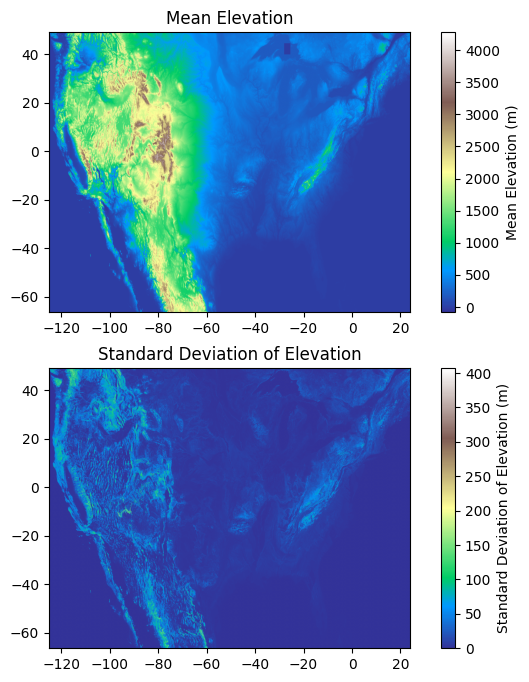

In [14]:
# plot meand and std elevation subplots
fig, ax = plt.subplots(2, 1, figsize=(8,8))

ax[0] = plot_elevation(GMTED_MN_DIR, bounds=(-125, 24, -66.5, 49), ax=ax[0])
ax[0].set_title('Mean Elevation')
ax[1] = plot_elevation(GMTED_SD_DIR, bounds=(-125, 24, -66.5, 49), ax=ax[1], a='Standard Deviation of Elevation (m)')
ax[1].set_title('Standard Deviation of Elevation')
plt.show()

### Slope

In [46]:
def plot_slope1(data_dir, bounds, ax=None):
    """Plot slope from neighboring mean elevation, from GMTED2010 data within specified bounds."""
    with rasterio.open(data_dir) as src:
        window = from_bounds(*bounds, transform=src.transform)
        data = src.read(1, window=window)
        extent = rasterio.windows.bounds(window, src.transform)

    # Calculate slope using numpy gradient
    dy, dx = np.gradient(data, edge_order=2)
    slope = np.sqrt(dx**2 + dy**2)

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))

    img = ax.imshow(slope, extent=extent, cmap='terrain', origin='upper')
    plt.colorbar(img, ax=ax, label='Slope (m/m)')
    return ax

In [47]:
def plot_slope2(data_dirs, bounds, ax=None):
    """Plot slope from min-max elevation range (relief), from GMTED2010 data within specified bounds."""
    with rasterio.open(data_dirs[0]) as src1:
        window = from_bounds(*bounds, transform=src1.transform)
        data1 = src1.read(1, window=window)
        extent = rasterio.windows.bounds(window, src1.transform)
    
    with rasterio.open(data_dirs[1]) as src2:
        window = from_bounds(*bounds, transform=src2.transform)
        data2 = src2.read(1, window=window)
        extent = rasterio.windows.bounds(window, src2.transform)
    
    # Calculate slope as difference between max and min elevation (relief)
    slope = data2 - data1

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))

    img = ax.imshow(slope, extent=extent, cmap='terrain', origin='upper')
    plt.colorbar(img, ax=ax, label='Slope (m/m)')
    return ax

In [48]:
def plot_slope3(data_dirs, bounds, ax=None):
    """Plot slope as normalized relief, from GMTED2010 data within specified bounds."""
    with rasterio.open(data_dirs[0]) as src1:
        window = from_bounds(*bounds, transform=src1.transform)
        min = src1.read(1, window=window)
        extent = rasterio.windows.bounds(window, src1.transform)
    
    with rasterio.open(data_dirs[1]) as src2:
        window = from_bounds(*bounds, transform=src2.transform)
        max = src2.read(1, window=window)
        extent = rasterio.windows.bounds(window, src2.transform)
    
    with rasterio.open(data_dirs[2]) as src3:
        window = from_bounds(*bounds, transform=src3.transform)
        mean = src3.read(1, window=window)
        extent = rasterio.windows.bounds(window, src3.transform)
    
    # Calculate slope as difference between max and min elevation
    slope = (max - min) / (mean + 1e-6)  # avoid division by zero
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))

    img = ax.imshow(slope, extent=extent, cmap='terrain', origin='upper')
    plt.colorbar(img, ax=ax, label='Slope (m/m)')
    return ax

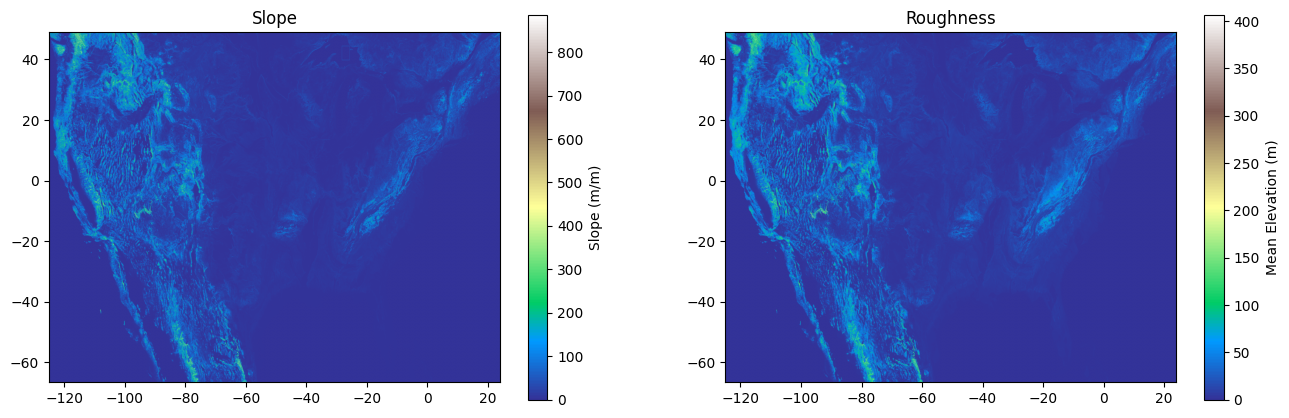

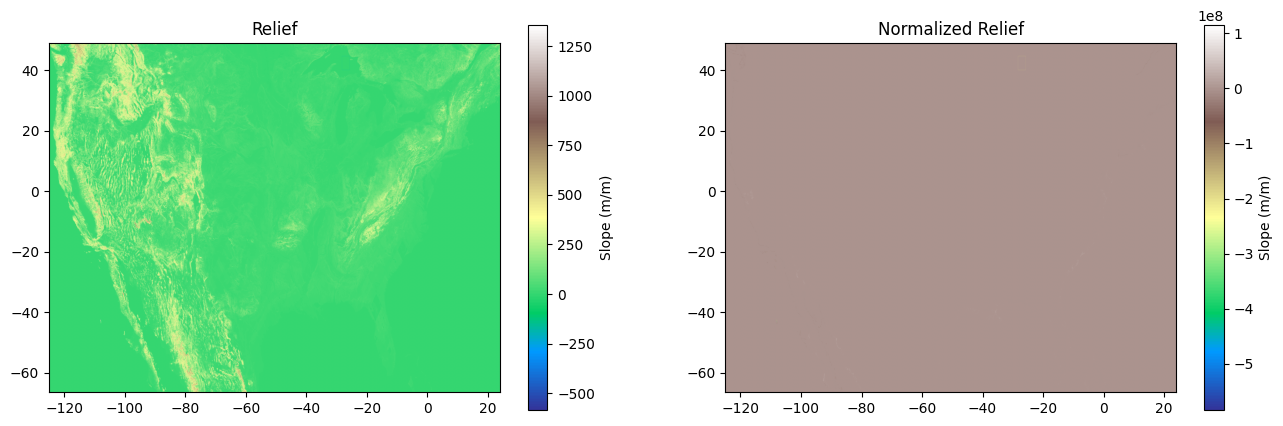

In [49]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0] = plot_slope1(GMTED_MN_DIR, bounds=(-125, 24, -66.5, 49), ax=ax[0])
ax[0].set_title('Slope')
ax[1] = plot_elevation(GMTED_SD_DIR, bounds=(-125, 24, -66.5, 49), ax=ax[1])
ax[1].set_title('Roughness')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0] = plot_slope2([GMTED_MI_DIR, GMTED_MX_DIR], bounds=(-125, 24, -66.5, 49), ax=ax[0])
ax[0].set_title('Relief')
ax[1] = plot_slope3([GMTED_MI_DIR, GMTED_MX_DIR, GMTED_MN_DIR], bounds=(-125, 24, -66.5, 49), ax=ax[1])
ax[1].set_title('Normalized Relief')
plt.show()





## Elevation and slope from coords

In [2]:
def gmted_features(lat, lon, radius_km, gmted_dirs):
    """Extract GMTED2010 features mean and std elevation around a point, linearly interpolating from the closest points."""
    features = {}
    for gmted_dir in gmted_dirs:
        with rasterio.open(gmted_dir) as src:
            # Convert radius from km to degrees (approximation)
            radius_deg = radius_km / 111.32
            bounds = (lon - radius_deg, lat - radius_deg, lon + radius_deg, lat + radius_deg)
            window = from_bounds(*bounds, transform=src.transform)
            data = src.read(1, window=window)
            mean_val = np.nanmean(data)
            std_val = np.nanmean(data)
            if 'mn' in os.path.basename(gmted_dir):
                features['mean_elevation'] = mean_val
            elif 'sd' in os.path.basename(gmted_dir):
                features['std_elevation'] = std_val
    return features   

In [3]:
def gmted_elevation(lat, lon, radius_km, gmted_dir):
    """Extract GMTED2010 elevation at a point, using nearest neighbor interpolation."""
    try:
        with rasterio.open(gmted_dir) as src:
            # Convert radius from km to degrees (approximation)
            radius_deg = radius_km / 111.32
            bounds = (lon - radius_deg, lat - radius_deg, lon + radius_deg, lat + radius_deg)
            window = from_bounds(*bounds, transform=src.transform)
            data = src.read(1, window=window)
            mean_val = np.nanmean(data)
            if 'mn' in os.path.basename(gmted_dir):
                return mean_val
            else:
                return np.nan
    except Exception as e:
        return np.nan

def gmted_slope(lat, lon, radius_km, gmted_dir):
    """Extract GMTED2010 elevation at a point, using nearest neighbor interpolation."""
    try:
        with rasterio.open(gmted_dir) as src:
            # Convert radius from km to degrees (approximation)
            radius_deg = radius_km / 111.32
            bounds = (lon - radius_deg, lat - radius_deg, lon + radius_deg, lat + radius_deg)
            window = from_bounds(*bounds, transform=src.transform)
            data = src.read(1, window=window)
            std_val = np.nanmean(data)
            if 'sd' in os.path.basename(gmted_dir):
                return std_val
            else:
                return np.nan
    except Exception as e:
        return np.nan

In [4]:
gmted_features(
    lat=39.7392,
    lon=-104.9903,   # Denver
    radius_km=10,
    gmted_dirs=[GMTED_MN_DIR, GMTED_SD_DIR]
)

NameError: name 'GMTED_MN_DIR' is not defined

## Add feats to the dataset

In [ ]:
# Define paths to the storm events CSV files
data_dir = Path('../datasets\\')
files = [
    data_dir / 'StormEvents_details-ftp_v1.0_d2016_c20250818.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2017_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2018_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2019_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2020_c20251118.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2021_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2022_c20250721.csv',
]

# Load datasets
print("Loading datasets...")
df_list = []
for file in files:
    # print(f"  Loading {file.name}...")
    df = pd.read_csv(file)
    # print(f"    Shape: {df.shape}")
    df_list.append(df)

# Concatenate the datasets
df = pd.concat(df_list, ignore_index=True)
print(f"\nCombined dataset shape: {df.shape}")

Loading datasets...

Combined dataset shape: (436146, 51)


In [62]:
df.drop(columns=[col for col in df.columns if col not in ['INDEX', 'BEGIN_LAT', 'BEGIN_LON']], inplace=True)
df.head()

,BEGIN_LAT,BEGIN_LON
0,34.94,-81.03
1,35.01,-80.93
2,35.64,-82.14
3,35.65,-84.18
4,35.87,-83.77


In [67]:
df['ELEVATION'] = np.nan
for idx, row in df.iterrows():
    df.loc[idx, 'ELEVATION'] = gmted_elevation(
        lat=row['BEGIN_LAT'],
        lon=row['BEGIN_LON'],
        radius_km=10,
        gmted_dir=GMTED_MN_DIR
    )
df['SLOPE'] = np.nan
for idx, row in df.iterrows():
    df.loc[idx, 'SLOPE'] = gmted_slope(
        lat=row['BEGIN_LAT'],
        lon=row['BEGIN_LON'],
        radius_km=10,
        gmted_dir=GMTED_SD_DIR
    )

df.head()

,BEGIN_LAT,BEGIN_LON,ELEVATION,SLOPE
0,34.94,-81.03,186.712810,5.619835
1,35.01,-80.93,184.066116,6.522727
2,35.64,-82.14,596.975207,39.692149
3,35.65,-84.18,280.250000,11.473140
4,35.87,-83.77,323.111570,15.723140


In [72]:
df.drop(columns=['BEGIN_LAT', 'BEGIN_LON'], inplace=True)
df.to_csv(data_dir / 'disasters_new_feats' / 'elevation.csv', index=False)